In [13]:
import os
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

os.makedirs("artifacts", exist_ok=True)

model = tf.keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", pooling="avg"
)
preprocess = tf.keras.applications.efficientnet.preprocess_input

In [14]:
exts = {".jpg",".jpeg",".png",".bmp",".tiff",".webp"}

def get_paths(folder):
    return [str(p) for p in Path(folder).rglob("*") if p.suffix.lower() in exts]

fresh_paths = get_paths("DataSet/Fresh")
rotten_paths = get_paths("DataSet/Rotten")

paths = fresh_paths + rotten_paths
labels = np.array([0]*len(fresh_paths) + [1]*len(rotten_paths))

def get_fruit(p):
    name = p.lower()
    for f in ["apple","banana","capsicum","cucumber","potato"]:
        if f in name:
            return f.capitalize()
    return "Unknown"

fruit_type = np.array([get_fruit(p) for p in paths])

print("Total:", len(paths))

Total: 13232


In [10]:
def get_fruit(path):
    name = path.lower()
    for f in ["apple","banana","capsicum","cucumber","potato"]:
        if f in name:
            return f.capitalize()
    return "Unknown"

fruit_type = np.array([get_fruit(p) for p in paths])

In [15]:
def extract_handcrafted(img):
    img = cv2.resize(img, (224,224))
    img = img.astype(np.float32)

    # ===== RGB (6) =====
    b,g,r = cv2.split(img)
    rgb = [r.mean(), g.mean(), b.mean(), r.std(), g.std(), b.std()]

    # ===== HSV (6) =====
    hsv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2HSV)
    h,s,v = hsv[:,:,0].astype(np.float32), hsv[:,:,1], hsv[:,:,2]

    h_rad = h * (2*np.pi/180)
    cx, sx = np.cos(h_rad).mean(), np.sin(h_rad).mean()
    h_mean = np.arctan2(sx, cx)
    R = np.sqrt(cx**2 + sx**2)
    h_std = np.sqrt(-2*np.log(R + 1e-6))

    hsv_feat = [h_mean, s.mean(), v.mean(), h_std, s.std(), v.std()]

    # ===== LAB (6) =====
    lab = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2LAB)
    l,a,b2 = lab[:,:,0], lab[:,:,1], lab[:,:,2]
    lab_feat = [l.mean(), l.std(), a.mean(), a.std(), b2.mean(), b2.std()]

    # ===== TEXTURE (5) =====
    gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY)

    lap = cv2.Laplacian(gray, cv2.CV_64F).var()

    g = (gray // 8).astype(np.uint8)  # reduce levels
    glcm = graycomatrix(g, distances=[1], angles=[0], levels=32, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    hist,_ = np.histogram(gray, bins=256, range=(0,255), density=True)
    ent = entropy(hist + 1e-6)

    texture = [lap, contrast, energy, homogeneity, ent]

    # ===== SHAPE (6) =====
    _,th = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    contours,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        peri = cv2.arcLength(c, True)

        circ = 4*np.pi*area/(peri*peri + 1e-6)

        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity = area/(hull_area + 1e-6)

        x,y,w,h = cv2.boundingRect(c)
        aspect = w/(h+1e-6)
        extent = area/(w*h + 1e-6)
    else:
        area=peri=circ=solidity=aspect=extent=0

    shape = [area, peri, circ, solidity, aspect, extent]

    # ===== DARK PIXEL (1) =====
    dark_ratio = (gray < 50).mean()

    return np.array(rgb + hsv_feat + lab_feat + texture + shape + [dark_ratio], dtype=np.float32)

In [16]:
def extract_features(paths, batch_size=32):
    all_feats = []

    for i in tqdm(range(0, len(paths), batch_size)):
        batch_paths = paths[i:i+batch_size]

        imgs = [cv2.imread(p) for p in batch_paths]
        imgs = [cv2.resize(img, (224,224)) for img in imgs]

        # ===== EfficientNet (BATCH) =====
        x = preprocess(np.array(imgs, dtype=np.float32))
        emb = model.predict(x, verbose=0)

        # ===== Handcrafted (single loop only) =====
        hand = np.array([extract_handcrafted(img) for img in imgs])

        # combine
        batch_feat = np.concatenate([emb, hand], axis=1)
        all_feats.append(batch_feat)

    return np.vstack(all_feats)

In [17]:
X = extract_features(paths)

np.save("artifacts/X.npy", X)
np.save("artifacts/y.npy", labels)
np.save("artifacts/fruit_type.npy", fruit_type)

print("Final shape:", X.shape)

100%|██████████| 414/414 [23:24<00:00,  3.39s/it]


Final shape: (13232, 1310)


# Feature Diagnosis

Loaded X shape: (13232, 1310)
After prefilter: (13232, 300)
k=60, CV Acc=0.9725
k=100, CV Acc=0.9789
k=140, CV Acc=0.9815

BEST FEATURE COUNT: 140


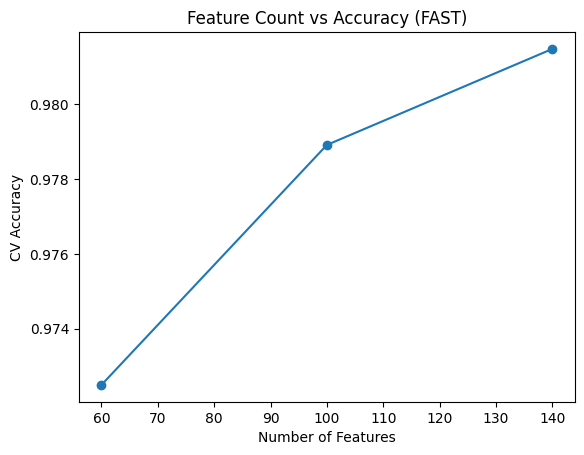

Selected feature shape: (13232, 140)


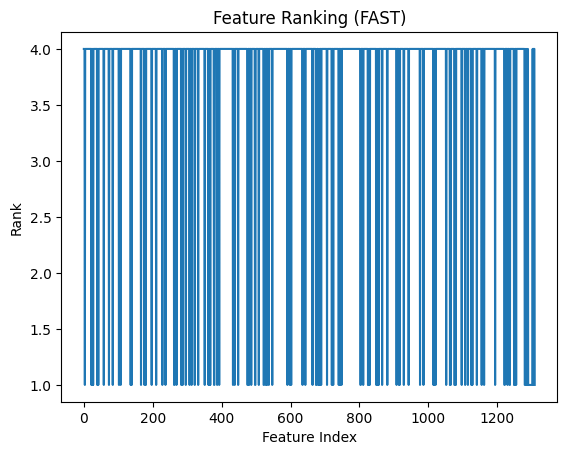

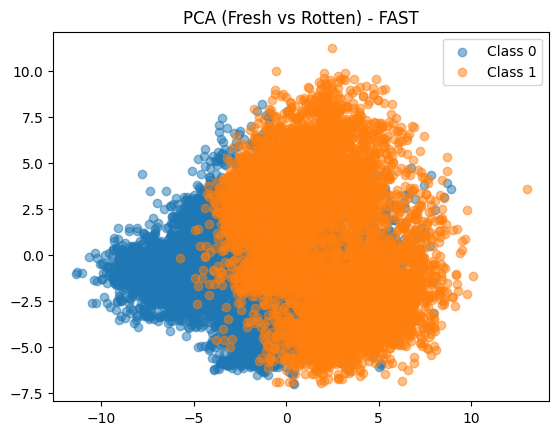

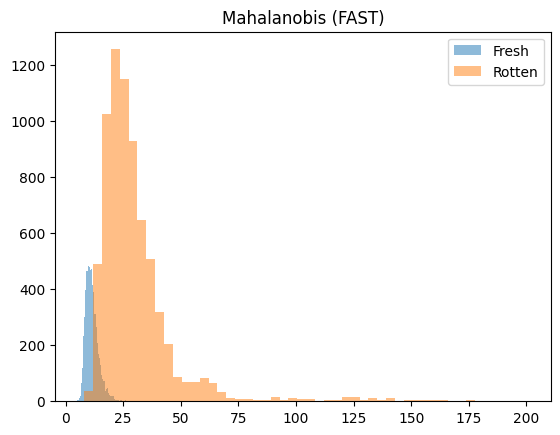

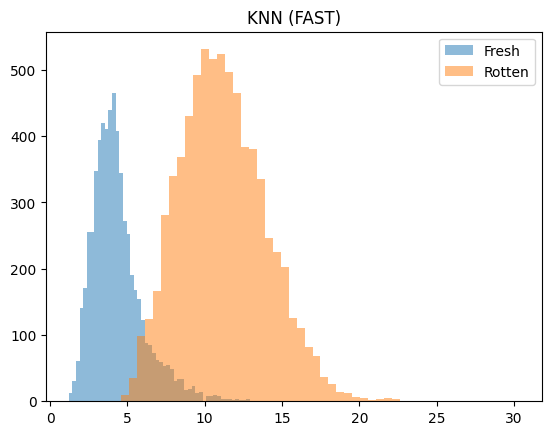


=== DASFS (FAST) ===


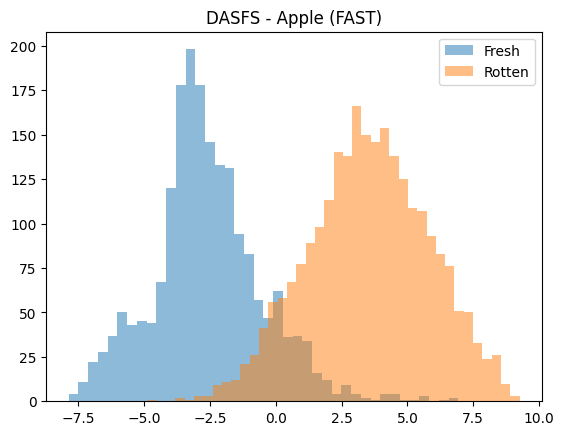

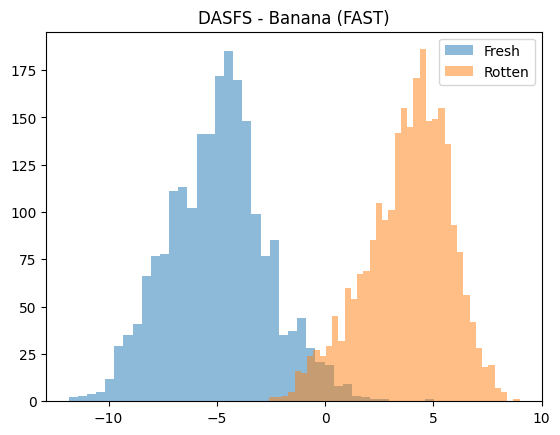

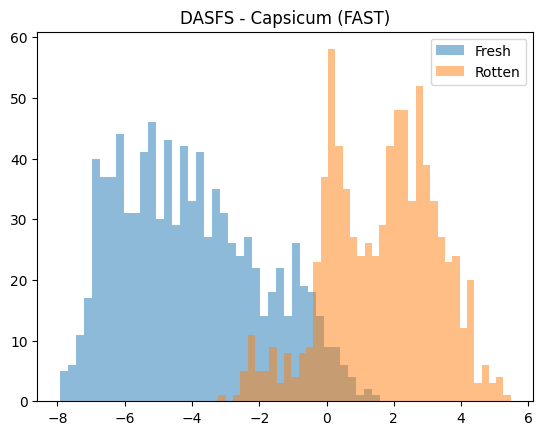

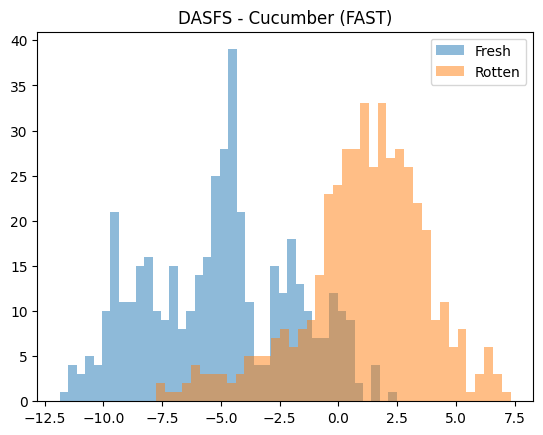

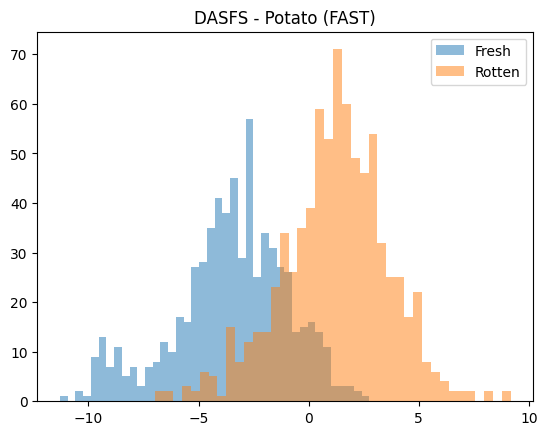


=== SEPARATION (FAST) ===
Mahalanobis: 0.8926756233168457
KNN        : 1.5357602306033464


In [5]:
# =========================
# IMPORTS
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import numpy.linalg as npl
import joblib

# =========================
# LOAD DATA
# =========================
X = np.load("artifacts/X.npy")           # fused features (1280+32)
y = np.load("artifacts/y.npy")
ft = np.load("artifacts/fruit_type.npy", allow_pickle=True)

print("Loaded X shape:", X.shape)

# =========================
# SAVE FUSED FEATURES
# =========================
np.save("artifacts/X_fused.npy", X)

# =========================
# SCALE FEATURES
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# OPTIONAL: PRE-FILTER (FAST)
# keep top 300 by MI (freshness)
# =========================
mi = mutual_info_classif(X_scaled, y)
topk_prefilter = 300
pref_idx = np.argsort(mi)[-topk_prefilter:]

X_pf = X_scaled[:, pref_idx]
print("After prefilter:", X_pf.shape)

# =========================
# CROSS-VALIDATION (FAST)
# =========================
feature_range = [60, 100, 140]   # reduced search
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for k in feature_range:
    accs = []

    for tr, val in skf.split(X_pf, y):
        X_tr, X_val = X_pf[tr], X_pf[val]
        y_tr, y_val = y[tr], y[val]

        # FAST RFE
        rfe = RFE(
            estimator=LinearSVC(dual=False, max_iter=3000),
            n_features_to_select=k,
            step=100
        )
        X_tr_sel = rfe.fit_transform(X_tr, y_tr)
        X_val_sel = rfe.transform(X_val)

        # keep final classifier same as before
        clf = SVC(kernel='rbf')
        clf.fit(X_tr_sel, y_tr)

        pred = clf.predict(X_val_sel)
        accs.append(accuracy_score(y_val, pred))

    mean_acc = np.mean(accs)
    results.append((k, mean_acc))
    print(f"k={k}, CV Acc={mean_acc:.4f}")

# =========================
# SELECT BEST k
# =========================
best_k = sorted(results, key=lambda x:(-x[1], x[0]))[0][0]
print("\nBEST FEATURE COUNT:", best_k)

# =========================
# PLOT ACCURACY CURVE
# =========================
ks = [r[0] for r in results]
accs = [r[1] for r in results]

plt.figure()
plt.plot(ks, accs, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("CV Accuracy")
plt.title("Feature Count vs Accuracy (FAST)")
plt.show()

# =========================
# FINAL RFE ON FULL DATA
# =========================
rfe = RFE(
    estimator=LinearSVC(dual=False, max_iter=3000),
    n_features_to_select=best_k,
    step=100
)

X_selected_pf = rfe.fit_transform(X_pf, y)

# map back to original indices
selected_in_pf = np.where(rfe.support_)[0]
final_idx = pref_idx[selected_in_pf]

X_selected = X_scaled[:, final_idx]

print("Selected feature shape:", X_selected.shape)

# save
np.save("artifacts/X_freshness.npy", X_selected)
joblib.dump(rfe, "models/rfe_freshness_fast.pkl")
np.save("artifacts/selected_idx_fast.npy", final_idx)

# =========================
# FEATURE IMPORTANCE CURVE
# =========================
ranking = np.ones(X.shape[1]) * (np.max(rfe.ranking_) + 1)
ranking[final_idx] = rfe.ranking_[rfe.support_]

plt.figure()
plt.plot(ranking)
plt.title("Feature Ranking (FAST)")
plt.xlabel("Feature Index")
plt.ylabel("Rank")
plt.show()

# =========================
# PCA CLUSTER CHECK
# =========================
pca = PCA(n_components=2)
Xp = pca.fit_transform(X_selected)

plt.figure()
for label in np.unique(y):
    idx = y == label
    plt.scatter(Xp[idx,0], Xp[idx,1], alpha=0.5, label=f"Class {label}")
plt.legend()
plt.title("PCA (Fresh vs Rotten) - FAST")
plt.show()

# =========================
# MAHALANOBIS
# =========================
def mahal(X, y, ft):
    M = np.zeros(len(X))
    for f in np.unique(ft):
        idx = (ft == f) & (y == 0)
        if idx.sum() < 5:
            continue
        Xf = X[idx]
        mu = Xf.mean(axis=0)
        cov = np.cov(Xf, rowvar=False) + 1e-6*np.eye(X.shape[1])
        inv = npl.pinv(cov)

        idx_all = (ft == f)
        diff = X[idx_all] - mu
        M[idx_all] = np.sqrt(np.sum(diff @ inv * diff, axis=1))
    return M

M = mahal(X_selected, y, ft)

plt.figure()
plt.hist(M[y==0], bins=50, alpha=0.5, label="Fresh")
plt.hist(M[y==1], bins=50, alpha=0.5, label="Rotten")
plt.legend()
plt.title("Mahalanobis (FAST)")
plt.show()

# =========================
# KNN
# =========================
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_selected[y==0])
K = knn.kneighbors(X_selected)[0].mean(axis=1)

plt.figure()
plt.hist(K[y==0], bins=50, alpha=0.5, label="Fresh")
plt.hist(K[y==1], bins=50, alpha=0.5, label="Rotten")
plt.legend()
plt.title("KNN (FAST)")
plt.show()

# =========================
# DASFS
# =========================
print("\n=== DASFS (FAST) ===")
for f in np.unique(ft):
    idx = (ft == f)
    fresh = X_selected[idx & (y==0)]
    rotten = X_selected[idx & (y==1)]
    if len(fresh) < 5 or len(rotten) < 5:
        continue

    mu_f = fresh.mean(axis=0)
    mu_r = rotten.mean(axis=0)

    axis = mu_r - mu_f
    axis = axis / (np.linalg.norm(axis) + 1e-8)

    proj = X_selected[idx] @ axis
    labels = y[idx]

    plt.figure()
    plt.hist(proj[labels==0], bins=40, alpha=0.5, label="Fresh")
    plt.hist(proj[labels==1], bins=40, alpha=0.5, label="Rotten")
    plt.title(f"DASFS - {f} (FAST)")
    plt.legend()
    plt.show()

# =========================
# NUMERIC SEPARATION
# =========================
def sep(a, b):
    return np.abs(a.mean() - b.mean()) / (a.std() + b.std() + 1e-8)

print("\n=== SEPARATION (FAST) ===")
print("Mahalanobis:", sep(M[y==0], M[y==1]))
print("KNN        :", sep(K[y==0], K[y==1]))

In [8]:
import numpy as np
x = np.load("artifacts/selected_idx_fast.npy")
x.shape

(140,)

In [ ]:
_